In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

print("Libraries loaded")

Libraries loaded


In [2]:
# Load windowed data
train = pd.read_csv('../data/windows_train.csv')
test  = pd.read_csv('../data/windows_cow04.csv')

# Load trained classifier and feature list
rf           = joblib.load('../models/rf_classifier.joblib')
feature_cols = joblib.load('../models/feature_cols.joblib')
baselines    = joblib.load('../models/baselines.joblib')

print(f"Training windows: {len(train):,}")
print(f"Test windows:     {len(test):,}")
print(f"Features:         {len(feature_cols)}")
print(f"\nBaseline animals: {list(baselines.keys())}")

Training windows: 85,978
Test windows:     16,867
Features:         19

Baseline animals: ['cow_01', 'cow_03', 'cow_04']


In [3]:
# Isolation Forest is sensitive to feature scale
# unlike Random Forest, so we normalize here
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[feature_cols])
X_test_scaled  = scaler.transform(test[feature_cols])

print("Features scaled")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Features scaled
X_train_scaled shape: (85978, 19)
X_test_scaled shape:  (16867, 19)


In [4]:
print("Training Isolation Forest...")

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.05,  # assume ~5% of windows are anomalous
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train_scaled)
print("Training complete")

Training Isolation Forest...
Training complete


In [5]:
# Get anomaly scores for cow_04
# score_samples returns negative values
# more negative = more anomalous
raw_scores = iso_forest.score_samples(X_test_scaled)

# Convert to 0-1 scale where higher = more anomalous
# for easier interpretation
anomaly_scores = -raw_scores

# Get binary prediction (-1 = anomaly, 1 = normal)
predictions = iso_forest.predict(X_test_scaled)
test = test.copy()
test['anomaly_score'] = anomaly_scores
test['is_anomaly']    = (predictions == -1).astype(int)

print("Anomaly scoring complete")
print(f"\nTotal windows:    {len(test):,}")
print(f"Flagged anomalies: {test['is_anomaly'].sum():,} ({test['is_anomaly'].mean()*100:.1f}%)")
print(f"\nAnomaly score stats:")
print(test['anomaly_score'].describe().round(4))

Anomaly scoring complete

Total windows:    16,867
Flagged anomalies: 2,481 (14.7%)

Anomaly score stats:
count    16867.0000
mean         0.4624
std          0.0711
min          0.3695
25%          0.4096
50%          0.4311
75%          0.5070
max          0.7715
Name: anomaly_score, dtype: float64


In [6]:
print("=== Anomaly flags by behavior ===\n")

for behavior in ['Eating', 'Ruminating', 'Other']:
    subset = test[test['behavior'] == behavior]
    flagged = subset['is_anomaly'].sum()
    total   = len(subset)
    print(f"{behavior:12s}: {flagged:5,} / {total:5,} flagged ({flagged/total*100:.1f}%)")

print("\n=== Mean anomaly score by behavior ===\n")
print(test.groupby('behavior')['anomaly_score'].mean().round(4))

=== Anomaly flags by behavior ===

Eating      :   645 / 2,859 flagged (22.6%)
Ruminating  :   405 / 6,136 flagged (6.6%)
Other       : 1,431 / 7,872 flagged (18.2%)

=== Mean anomaly score by behavior ===

behavior
Eating        0.4944
Other         0.4748
Ruminating    0.4317
Name: anomaly_score, dtype: float64


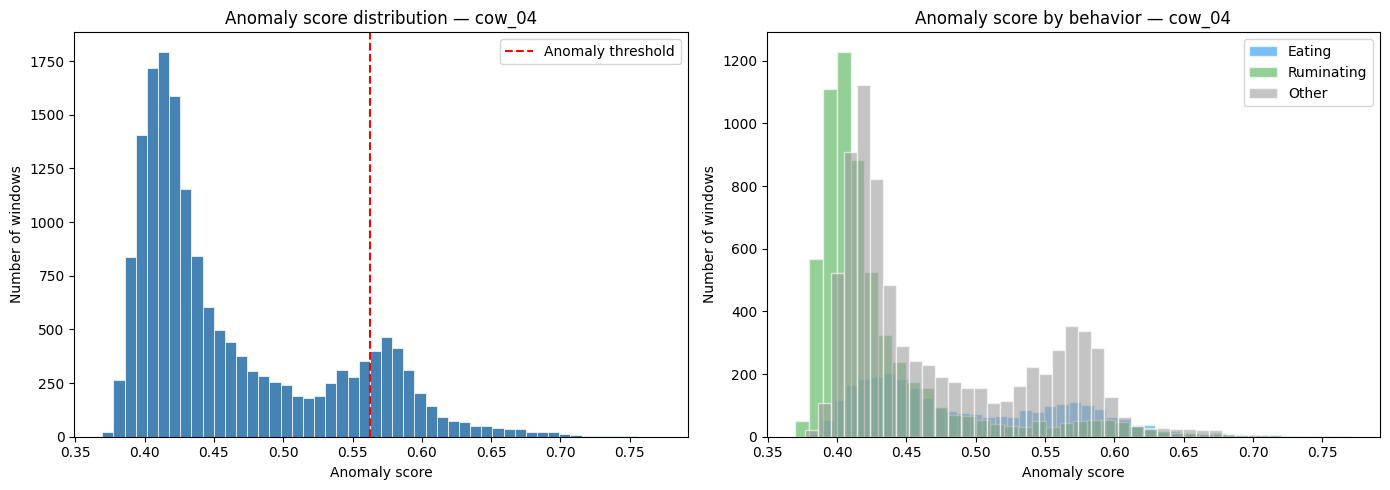

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: overall score distribution
axes[0].hist(test['anomaly_score'], bins=50, 
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(test[test['is_anomaly']==1]['anomaly_score'].min(),
                color='red', linestyle='--', linewidth=1.5,
                label='Anomaly threshold')
axes[0].set_xlabel('Anomaly score')
axes[0].set_ylabel('Number of windows')
axes[0].set_title('Anomaly score distribution — cow_04')
axes[0].legend()

# Right: score by behavior
colors = {'Eating': '#2196F3', 'Ruminating': '#4CAF50', 'Other': '#9E9E9E'}
for behavior, color in colors.items():
    subset = test[test['behavior'] == behavior]['anomaly_score']
    axes[1].hist(subset, bins=40, alpha=0.6, 
                 color=color, label=behavior, edgecolor='white')

axes[1].set_xlabel('Anomaly score')
axes[1].set_ylabel('Number of windows')
axes[1].set_title('Anomaly score by behavior — cow_04')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/anomaly_scores.png', dpi=100)
plt.show()

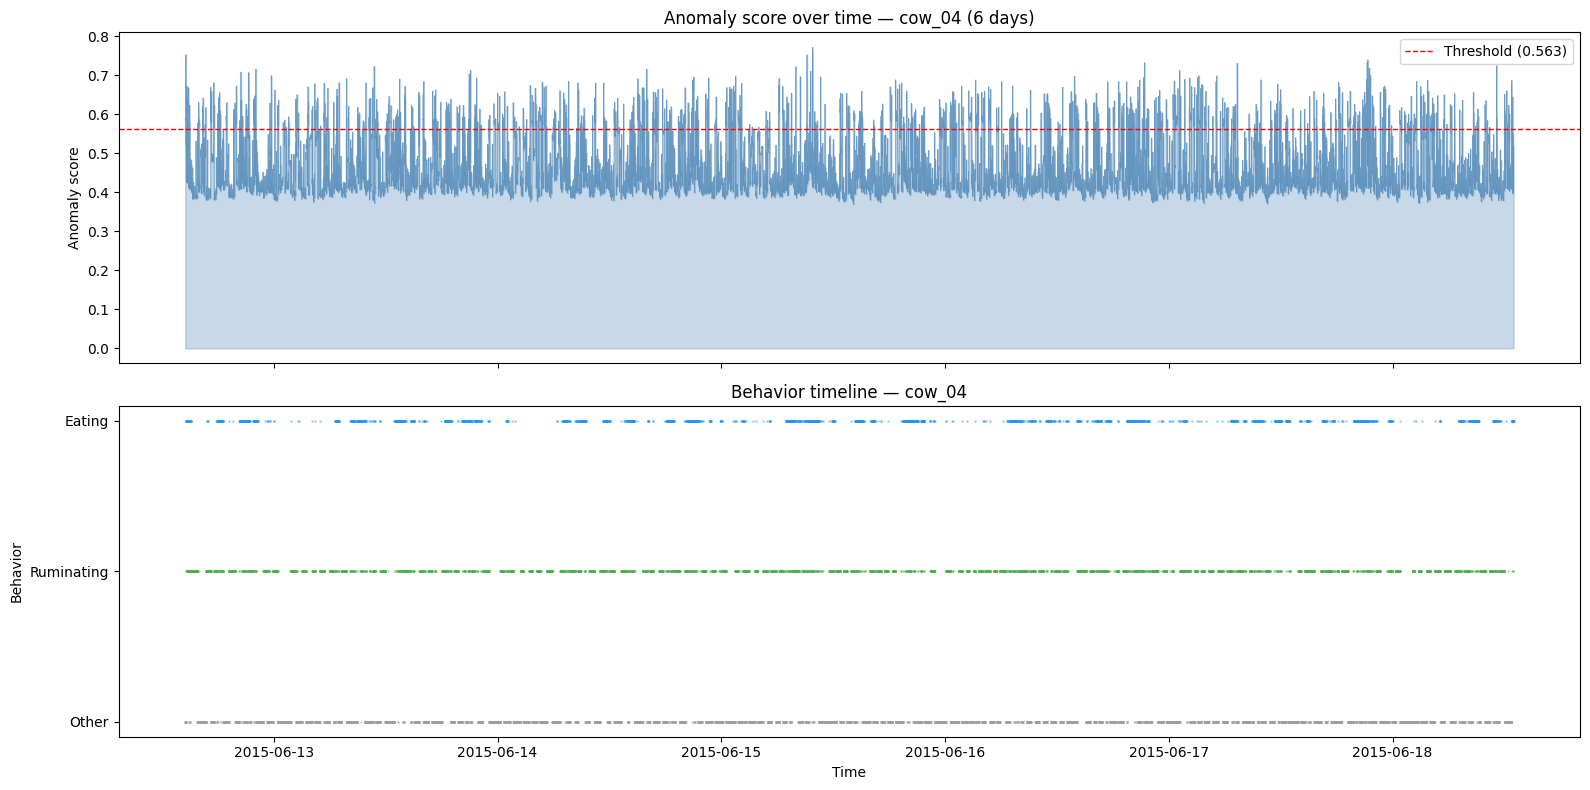

In [8]:
test['window_start'] = pd.to_datetime(test['window_start'])

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

# Top: anomaly score over time
axes[0].plot(test['window_start'], test['anomaly_score'],
             color='steelblue', linewidth=0.5, alpha=0.7)
axes[0].fill_between(test['window_start'], test['anomaly_score'],
                      alpha=0.3, color='steelblue')
threshold = test[test['is_anomaly']==1]['anomaly_score'].min()
axes[0].axhline(threshold, color='red', linestyle='--', 
                linewidth=1, label=f'Threshold ({threshold:.3f})')
axes[0].set_ylabel('Anomaly score')
axes[0].set_title('Anomaly score over time — cow_04 (6 days)')
axes[0].legend()

# Bottom: behavior over time (color coded)
behavior_map = {'Eating': 2, 'Ruminating': 1, 'Other': 0}
test['behavior_num'] = test['behavior'].map(behavior_map)

color_map = {2: '#2196F3', 1: '#4CAF50', 0: '#9E9E9E'}
for bnum, color in color_map.items():
    mask = test['behavior_num'] == bnum
    axes[1].scatter(test[mask]['window_start'], 
                    test[mask]['behavior_num'],
                    c=color, s=1, alpha=0.3)

axes[1].set_yticks([0, 1, 2])
axes[1].set_yticklabels(['Other', 'Ruminating', 'Eating'])
axes[1].set_ylabel('Behavior')
axes[1].set_xlabel('Time')
axes[1].set_title('Behavior timeline — cow_04')

plt.tight_layout()
plt.savefig('../data/anomaly_timeline.png', dpi=100)
plt.show()

In [9]:
joblib.dump(iso_forest, '../models/isolation_forest.joblib')
joblib.dump(scaler,     '../models/scaler.joblib')
test.to_csv('../data/cow04_scored.csv', index=False)

print("Saved:")
print("  ../models/isolation_forest.joblib")
print("  ../models/scaler.joblib")
print("  ../data/cow04_scored.csv")

Saved:
  ../models/isolation_forest.joblib
  ../models/scaler.joblib
  ../data/cow04_scored.csv
